### Naive Bayes Classifier on Titaninc Dataset

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns

In [45]:
df = sns.load_dataset('titanic')

In [46]:
df = df[['pclass', 'sex', 'age', 'fare', 'survived']]

In [47]:
df.head()

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [48]:
X = df.drop(columns = ['survived'])
y = df.survived

In [49]:
X.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [50]:
df.isnull().sum()

pclass        0
sex           0
age         177
fare          0
survived      0
dtype: int64

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 4), (179, 4), (712,), (179,))

In [67]:
from sklearn.preprocessing import  StandardScaler,OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB

In [77]:
num_features = X_train.select_dtypes(include = ['number']).columns
cat_features = X_train.select_dtypes(include = ['object', 'category']).columns


num_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps = [
    ('ohe', OneHotEncoder(sparse_output = False))
])

preprocessor = ColumnTransformer(transformers = [
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('clf', GaussianNB())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [78]:
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_pred), r2_score(y_test, y_pred)

(0.776536312849162, 0.0785070785070785)

In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       105
           1       0.74      0.72      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [80]:
confusion_matrix(y_test, y_pred)

array([[86, 19],
       [21, 53]])

### Iris Dataset

In [84]:

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

In [87]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['Species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [89]:
X = df.drop(columns = ['Species'])
y = df.Species

label_enc  = LabelEncoder()
y = label_enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [91]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[40.,41.,39.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.34,0.33]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.045e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[4.99,3.45,1.45,0.24], [5.92,2.77,4.24,1.32], [6.53,2.97,5.52,2. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.12,0.15,0.03,0.01], [0.29,0.1 ,0.23,0.04], [0.42,0.1 ,0.29,0.08]]"


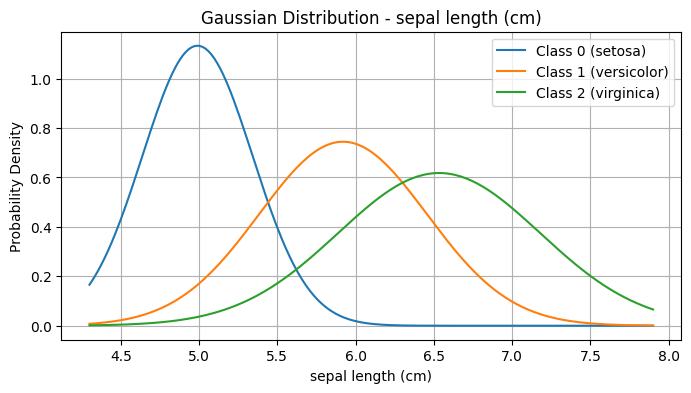

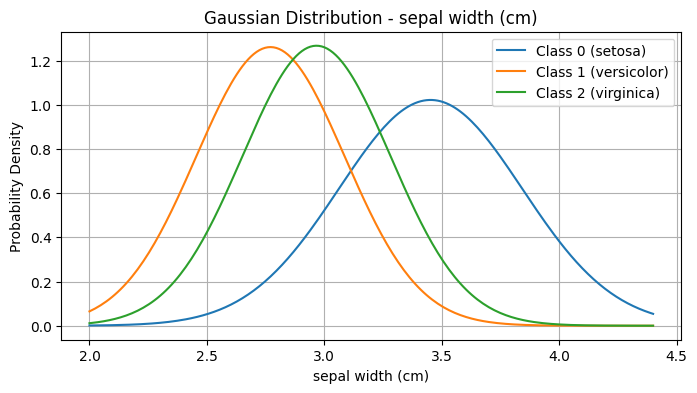

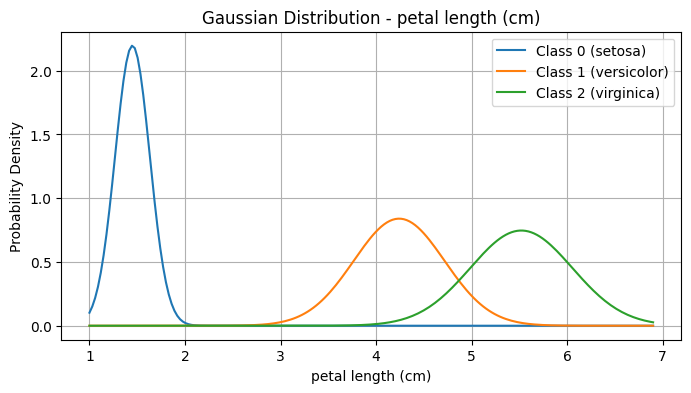

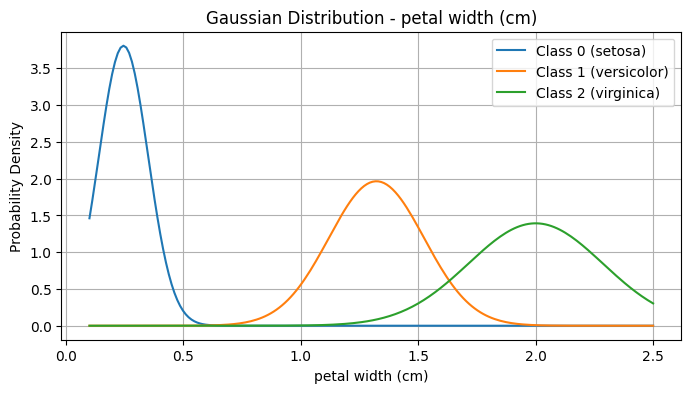

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

feature_names = iris.feature_names
num_features = len(feature_names)
num_classes = len(np.unique(y))

X_np = X.to_numpy() 

for feature_index in range(num_features):
    feature_name = feature_names[feature_index]
    x_vals = np.linspace(X_np[:, feature_index].min(), X_np[:, feature_index].max(), 200)

    plt.figure(figsize=(8, 4))

    for cls in range(num_classes):
        mean = gnb.theta_[cls, feature_index]
        std = np.sqrt(gnb.var_[cls, feature_index])
        y_vals = norm.pdf(x_vals, mean, std)
        plt.plot(x_vals, y_vals, label=f"Class {cls} ({iris.target_names[cls]})")

    plt.title(f"Gaussian Distribution - {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True)

    plt.show()

In [93]:
y_pred = gnb.predict(X_test)

In [94]:
r2_score(y_test, y_pred)

1.0

In [95]:
accuracy_score(y_test, y_pred)

1.0

In [97]:
confusion_matrix(y_test,y_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [99]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

